In [31]:
import sys
sys.path.append('../functions')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from plotnine import *

# Linear regression results

In [41]:
# Confidence set on the mean
sim_result = pd.read_csv('../functions/linear26042023.csv')
print(np.unique(sim_result.data_kwargs))
print(np.unique(sim_result.model_kwargs_l))
sim_result = sim_result[['L','N', 'p', 'method','Lower_bound', 'contain', 'Upper_bound', 'points_in_e1', 'inner_points_num','outer_points_num']]
sim_result_sub = sim_result[sim_result.N!=800][sim_result.method=='CS_on_mean']
t = sim_result_sub.drop(columns = ['p', 'Lower_bound']).rename(columns = {'L':'TLB',
                                                                  'contain':'Coverage',
                                                                  'Upper_bound':'EUB',
                                                                  'points_in_e1':'Points in IB',
                                                                  'inner_points_num':'Inner Set',
                                                                  'outer_points_num':'Outer set'
                                                  }).groupby(['TLB','N']).mean().round(2)
print(t.to_latex())

['{}']
['[{}]']
\begin{tabular}{llrrrrr}
\toprule
    &     &  Coverage &   EUB &  Points in IB &  Inner Set &  Outer set \\
TLB & N &           &       &               &            &            \\
\midrule
0.6 & 100 &      0.86 &  0.89 &          2.98 &       5.33 &       7.58 \\
    & 200 &      0.85 &  0.88 &          2.27 &       7.77 &       9.47 \\
    & 400 &      0.89 &  0.92 &          3.44 &       5.35 &       6.14 \\
0.9 & 100 &      0.94 &  0.98 &          2.57 &       4.23 &       7.55 \\
    & 200 &      0.92 &  0.97 &          2.10 &       5.37 &       8.64 \\
    & 400 &      0.95 &  0.97 &          1.54 &       6.73 &       8.90 \\
\bottomrule
\end{tabular}



In [81]:
# Confidence set on the true outcome
sim_result_sub = sim_result[sim_result.p==3][sim_result.N!=800][sim_result.on_y==1]
t = sim_result_sub.drop(columns = ['p', 'Lower_bound','on_y']).rename(columns = {'L':'TLB',
                                                                  'contain':'Coverage',
                                                                  'Upper_bound':'EUB',
                                                                  'points_in_e1':'Points in IB',
                                                                  'inner_points_num':'Inner Set',
                                                                  'true_set_points_num':'True Set',
                                                                  'outer_points_num':'Outer set'
                                                  }).groupby(['TLB','N']).mean().round(2)
print(t.to_latex())

\begin{tabular}{llrrrrrr}
\toprule
    &     &  Coverage &   EUB &  Points in IB &  Inner Set &  Outer set &  True Set \\
TLB & N &           &       &               &            &            &           \\
\midrule
0.6 & 100 &      0.85 &  0.85 &         54.18 &      49.60 &     450.35 &    250.17 \\
    & 200 &      0.79 &  0.84 &         58.25 &      48.78 &     452.18 &    249.10 \\
    & 400 &      0.83 &  0.84 &         61.91 &      53.67 &     445.74 &    249.69 \\
0.9 & 100 &      0.93 &  0.96 &         35.95 &      36.69 &     463.47 &    250.52 \\
    & 200 &      0.94 &  0.96 &         34.33 &      38.17 &     461.58 &    249.88 \\
    & 400 &      0.95 &  0.96 &         37.05 &      40.21 &     459.63 &    249.93 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_460/1320102581.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sim_result_sub = sim_result[sim_result.p==3][sim_result.N!=800][sim_result.on_y==1]
/tmp/ipykernel_460/1320102581.py:11: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(t.to_latex())


In [82]:
# Appendix table
sim_result_sub = sim_result[sim_result.p!=3]
t = sim_result_sub.drop(columns = ['p', 'Lower_bound']).rename(columns = {'L':'TLB',
                                                                  'contain':'Coverage',
                                                                  'Upper_bound':'EUB',
                                                                  'points_in_e1':'Points in IB',
                                                                  'inner_points_num':'Inner Set',
                                                                  'true_set_points_num':'True Set',
                                                                  'outer_points_num':'Outer set'
                                                  }).groupby(['on_y','TLB','N']).mean().round(2)
print(t.to_latex())

\begin{tabular}{lllrrrrrr}
\toprule
  &     &     &  Coverage &   EUB &  Points in IB &  Inner Set &  Outer set &  True Set \\
on\_y & TLB & N &           &       &               &            &            &           \\
\midrule
0 & 0.6 & 100 &      0.75 &  0.85 &         14.90 &     211.61 &     287.98 &    249.66 \\
  &     & 200 &      0.74 &  0.83 &         10.59 &     226.23 &     273.18 &    249.70 \\
  &     & 400 &      0.67 &  0.82 &          7.83 &     235.00 &     264.84 &    249.71 \\
  &     & 800 &      0.68 &  0.81 &          6.02 &     241.44 &     259.60 &    250.51 \\
  & 0.9 & 100 &      0.91 &  0.96 &         11.83 &     201.15 &     298.55 &    249.74 \\
  &     & 200 &      0.90 &  0.95 &          8.16 &     219.16 &     279.98 &    249.66 \\
  &     & 400 &      0.91 &  0.95 &          6.17 &     230.16 &     270.05 &    250.18 \\
  &     & 800 &      0.90 &  0.95 &          5.32 &     237.39 &     263.11 &    250.24 \\
1 & 0.6 & 100 &      0.86 &  0.85 &        

/tmp/ipykernel_460/811486233.py:11: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(t.to_latex())


# Logistic Regression Result

In [83]:
# Confidence set on the mean
sim_result = pd.read_csv('../functions/linear_result/logistic_sim_18032023.csv')
print(np.unique(sim_result.data_kwargs))
print(np.unique(sim_result.model_kwargs_l))
sim_result = sim_result[['L','method','N', 'p', 'Lower_bound', 'contain', 'Upper_bound', 'points_in_e1', 'inner_points_num','outer_points_num', 'true_set_points_num']]
sim_result_sub = sim_result[sim_result.p==3][sim_result.N!=800][sim_result.on_y==0]
t = sim_result_sub.drop(columns = ['p', 'Lower_bound','on_y']).rename(columns = {'L':'TLB',
                                                                  'contain':'Coverage',
                                                                  'Upper_bound':'EUB',
                                                                  'points_in_e1':'Points in IB',
                                                                  'inner_points_num':'Inner Set',
                                                                  'true_set_points_num':'True Set',
                                                                  'outer_points_num':'Outer set'
                                                  }).groupby(['TLB','N']).mean().round(2)
print(t.to_latex())

["{'binary': True, 'uniform_range_beta': [1, 3], 'uniform_range_x': [-2, 2]}"]
['[{}]']
\begin{tabular}{llrrrrrr}
\toprule
    &     &  Coverage &   EUB &  Points in IB &  Inner Set &  Outer set &  True Set \\
TLB & N &           &       &               &            &            &           \\
\midrule
0.6 & 100 &      0.74 &  0.90 &         18.61 &     180.46 &     278.03 &    231.09 \\
    & 200 &      0.75 &  0.88 &         14.04 &     195.23 &     262.63 &    231.19 \\
    & 400 &      0.79 &  0.86 &         10.57 &     208.08 &     253.28 &    231.70 \\
0.9 & 100 &      0.86 &  0.97 &         16.13 &     167.96 &     289.38 &    231.91 \\
    & 200 &      0.90 &  0.97 &         10.92 &     186.63 &     271.83 &    230.59 \\
    & 400 &      0.93 &  0.96 &          8.24 &     201.63 &     259.47 &    230.90 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_460/3428969673.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sim_result_sub = sim_result[sim_result.p==3][sim_result.N!=800][sim_result.on_y==0]
/tmp/ipykernel_460/3428969673.py:15: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(t.to_latex())


In [85]:
# Appendix table
sim_result_sub = sim_result[sim_result.p!=3]
t = sim_result_sub.drop(columns = ['p', 'Lower_bound','on_y']).rename(columns = {'L':'TLB',
                                                                  'contain':'Coverage',
                                                                  'Upper_bound':'EUB',
                                                                  'points_in_e1':'Points in IB',
                                                                  'inner_points_num':'Inner Set',
                                                                  'true_set_points_num':'True Set',
                                                                  'outer_points_num':'Outer set'
                                                  }).groupby(['TLB','N']).mean().round(2)
print(t.to_latex())

\begin{tabular}{llrrrrrr}
\toprule
    &     &  Coverage &   EUB &  Points in IB &  Inner Set &  Outer set &  True Set \\
TLB & N &           &       &               &            &            &           \\
\midrule
0.6 & 100 &      0.30 &  0.94 &         26.99 &     152.88 &     312.87 &    240.62 \\
    & 200 &      0.40 &  0.91 &         17.51 &     183.54 &     288.83 &    240.55 \\
    & 400 &      0.52 &  0.88 &         13.35 &     203.55 &     273.03 &    241.19 \\
    & 800 &      0.60 &  0.86 &         10.20 &     216.42 &     262.84 &    241.22 \\
0.9 & 100 &      0.48 &  0.99 &         40.83 &     140.11 &     327.20 &    240.62 \\
    & 200 &      0.57 &  0.98 &         18.24 &     175.70 &     297.07 &    240.75 \\
    & 400 &      0.70 &  0.97 &         11.72 &     197.30 &     279.79 &    240.83 \\
    & 800 &      0.78 &  0.96 &          8.73 &     211.26 &     268.01 &    240.60 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_460/808326971.py:11: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(t.to_latex())


# Non-linear result

In [5]:
sim_result = pd.read_csv('../functions/non_linear_result/neural_net_sim_25032023.csv')
print(np.unique(sim_result.data_kwargs))
print(np.unique(sim_result.model_kwargs_l))
sim_result = sim_result[['L','on_y','N', 'p', 'Lower_bound', 'contain', 'Upper_bound', 'points_in_e1', 'inner_points_num','outer_points_num', 'true_set_points_num']]
sim_result_sub = sim_result[sim_result.p==1][sim_result.N!=800][sim_result.on_y==0]
t = sim_result_sub.drop(columns = ['p', 'Lower_bound','on_y']).rename(columns = {'L':'TLB',
                                                                  'contain':'Coverage',
                                                                  'Upper_bound':'EUB',
                                                                  'points_in_e1':'Points in IB',
                                                                  'inner_points_num':'Inner Set',
                                                                  'true_set_points_num':'True Set',
                                                                  'outer_points_num':'Outer set'
                                                  }).groupby(['TLB','N']).mean().round(2)
print(t)
print(t.to_latex())

["{'transform_func': <function transform_X at 0x7fa992f71ea0>, 'beta': array([1, 2, 3, 4]), 'uniform_range_x': [-2, 2]}"]
["[{'n_iter': 200, 'patience': 100, 'input_size': 1, 'h_sizes': [40, 40]}]"]
         Coverage   EUB  Points in IB  Inner Set  Outer set  True Set
TLB N                                                                
0.6 100      0.81  0.88         10.74     244.89     299.66    266.40
    200      0.76  0.85          7.85     253.37     284.49    265.51
    400      0.71  0.83          6.51     259.21     276.87    266.26
0.9 100      0.93  0.97         10.25     238.92     316.79    266.79
    200      0.94  0.96          6.90     249.56     294.70    266.19
    400      0.92  0.95          5.52     255.43     283.36    266.40
\begin{tabular}{llrrrrrr}
\toprule
    &     &  Coverage &   EUB &  Points in IB &  Inner Set &  Outer set &  True Set \\
TLB & N &           &       &               &            &            &           \\
\midrule
0.6 & 100 &      0.81 &  

/tmp/ipykernel_492/2787226322.py:15: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(t.to_latex())


In [5]:
sim_result_sub = sim_result[sim_result.p==1][sim_result.N!=800][sim_result.on_y==1]
t = sim_result_sub.drop(columns = ['p', 'Lower_bound','on_y']).rename(columns = {'L':'TLB',
                                                                  'contain':'Coverage',
                                                                  'Upper_bound':'EUB',
                                                                  'points_in_e1':'Points in IB',
                                                                  'inner_points_num':'Inner Set',
                                                                  'true_set_points_num':'True Set',
                                                                  'outer_points_num':'Outer set'
                                                  }).groupby(['TLB','N']).mean().round(2)
print(t)
print(t.to_latex())

         Coverage   EUB  Points in IB  Inner Set  Outer set  True Set
TLB N                                                                
0.6 100      0.93  0.88         27.37     108.52     301.28    210.60
    200      0.87  0.85         23.13     125.09     283.00    209.75
    400      0.84  0.85         20.97     133.46     277.67    209.92
0.9 100      1.00  0.97         31.17      77.72     332.42    210.41
    200      0.98  0.96         17.71     106.24     302.57    209.67
    400      0.94  0.96         16.28     115.12     293.61    210.02
\begin{tabular}{llrrrrrr}
\toprule
    &     &  Coverage &   EUB &  Points in IB &  Inner Set &  Outer set &  True Set \\
TLB & N &           &       &               &            &            &           \\
\midrule
0.6 & 100 &      0.93 &  0.88 &         27.37 &     108.52 &     301.28 &    210.60 \\
    & 200 &      0.87 &  0.85 &         23.13 &     125.09 &     283.00 &    209.75 \\
    & 400 &      0.84 &  0.85 &         20.97 &   

/tmp/ipykernel_527/1146546493.py:11: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(t.to_latex())


# Interpretation of black box algorithms

In [33]:
sim_inter_result = pd.read_csv('sim_results_interpretation25112022.csv')


In [45]:
temp_table = sim_inter_result.loc[sim_inter_result.N!=50, ['N', 'p', 'N_test','contain', 'all_causal', 'percent_causal_selected']].groupby(['N', 'p', 'N_test']).mean()


In [46]:
print(temp_table.to_latex())# This for p_casual=20

\begin{tabular}{lllrrr}
\toprule
      &      &        &  contain &  all\_causal &  percent\_causal\_selected \\
N & p & N\_test &          &             &                          \\
\midrule
100.0 & 50.0 & 200.0  &    1.000 &       1.000 &                   0.0122 \\
      &      & 500.0  &    1.000 &       1.000 &                   0.0602 \\
      &      & 1000.0 &    1.000 &       0.998 &                   0.1171 \\
200.0 & 50.0 & 200.0  &    0.984 &       1.000 &                   0.1073 \\
      &      & 500.0  &    0.984 &       1.000 &                   0.2935 \\
      &      & 1000.0 &    0.976 &       0.992 &                   0.4238 \\
\bottomrule
\end{tabular}



In [27]:
df_plot = sim_inter_result.groupby(['N', 'p', 'p_causal']).mean().reset_index()
df_plot["p"] = df_plot["p"].astype("category")
df_plot = df_plot[df_plot.p==50]

In [28]:
df_plot

,N,p,p_causal,contain,all_causal,percent_causal_selected,N_test,error_sd,level,L
0,200.0,50.0,10.0,0.978,0.990,0.4312,500.0,1.0,0.0,0.95
1,200.0,50.0,20.0,0.988,1.000,0.3090,500.0,1.0,0.0,0.95
4,400.0,50.0,10.0,0.944,0.998,0.4704,500.0,1.0,0.0,0.95
5,400.0,50.0,20.0,0.962,1.000,0.3031,500.0,1.0,0.0,0.95


In [29]:
df_plot = pd.melt(df_plot, id_vars=['N', 'p', 'p_causal'], value_vars= ['all_causal', 'percent_causal_selected'], var_name= 'Type', value_name='Percentage')
df_plot["p_causal"] = df_plot["p_causal"].astype("category")

In [30]:
df_plot

,N,p,p_causal,Type,Percentage
0,200.0,50.0,10.0,all_causal,0.9900
1,200.0,50.0,20.0,all_causal,1.0000
2,400.0,50.0,10.0,all_causal,0.9980
3,400.0,50.0,20.0,all_causal,1.0000
4,200.0,50.0,10.0,percent_causal_selected,0.4312
5,200.0,50.0,20.0,percent_causal_selected,0.3090
6,400.0,50.0,10.0,percent_causal_selected,0.4704
7,400.0,50.0,20.0,percent_causal_selected,0.3031


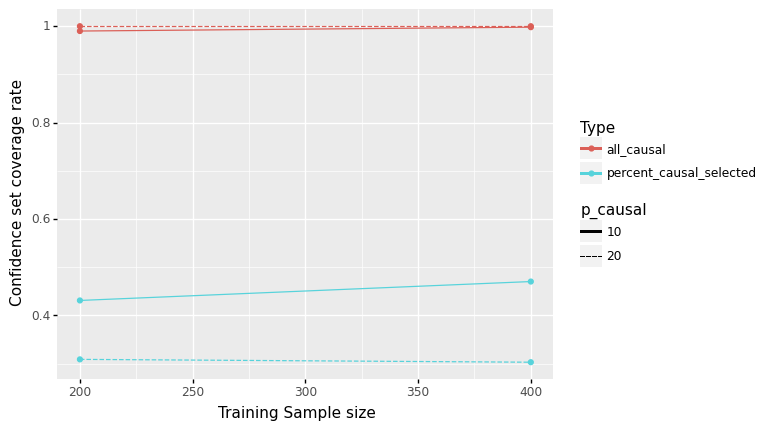

In [32]:
coverage_plot = (ggplot(df_plot)+
 geom_line(aes(x = 'N', y = 'Percentage', color = 'Type', linetype = 'p_causal'))+
 geom_point(aes(x = 'N', y = 'Percentage', color = 'Type'))+
 #geom_ribbon(aes(x = 'N',ymin='Lower_bound', ymax='Upper_bound',fill = 'p'), alpha=0.1)+
 #ylim(0.5, 1)+
 # scale_x_continuous(breaks=np.array(df_plot.N[~df_plot.N.duplicated()]))+
 # scale_y_continuous(breaks=[0, 0.5, 0.55, 0.6,0.65, 0.7,0.75,0.8,0.85, 0.9,0.95, 1])+
 ylab('Confidence set coverage rate')+
 xlab('Training Sample size')
)
#coverage_plot.save('results/coverage_plot_linear.png',dpi = 300)
coverage_plot.draw()